## Transient 2

Define the model for the transient event

In [60]:
import numpy as np
import dynesty
import matplotlib.pyplot as plt
from scipy.stats import norm
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import astropy.visualization.hist
import warnings
warnings.simplefilter("ignore", category=RuntimeWarning)



def plot(labels,sresults):
    rfig, raxes = dyplot.runplot(sresults)
    tfig, taxes = dyplot.traceplot(sresults,labels=labels)
    cfig, caxes = dyplot.cornerplot(sresults, labels=labels)

    Z = np.exp(sresults.logz[-1])
    # Resample weighted samples.
    weights = sresults.importance_weights()
    samples = sresults.samples
    samples_equal = dyfunc.resample_equal(samples, weights)

    # plot the histogram
    fig, axes = plt.subplots(1, ndim, figsize=(4*ndim, 4))
    for i in range(ndim):
        ax = axes[i]
        astropy.visualization.hist(samples_equal[:, i], bins="freedman",density=True, ax=ax)
        #ax.hist(emcee_trace[:, i], bins=50, color='skyblue', edgecolor='k', alpha=0.7,density=True)
        ax.set_xlabel(labels[i])
        ax.set_title(f"Histogram of {labels[i]}")
    axes[0].set_ylabel("Frequency")


    # Compute statistics
    medians = np.median(samples_equal, axis=0)
    q5 = np.percentile(samples_equal, 5, axis=0)
    q95 = np.percentile(samples_equal, 95, axis=0)
    ul = q95-medians
    ll = medians-q5
    # Print results
    for i, label in enumerate(labels):
        print(f"{label}: median = {medians[i]:.4f}, 5th = {q5[i]:.4f}, 95th = {q95[i]:.4f}. 90% credible region: {medians[i]:.4f}(+{ul[i]:4f}, -{ll[i]:4f})")
    
    return Z


def burst(x, time):

    b, t0, A, alpha = x
    y = np.where(time < t0,
                 b,
                 b + A * np.exp(-alpha * (time - t0)))
    return y

Define the loglikelihood and prior transformation that converts the sampling from the hypercube (from 0 to 1) to the desired one

Assuming a gaussian noise, the likelihood is $$ p(y_i|t_i, M(b, t_0, A, \alpha), \sigma) = N(y_i - M(x_i,b, t_0, A, \alpha)|\sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( - \frac{(y_i - M(b, t_0, A, \alpha,x_i))^2}{2 \sigma^2} \right). $$

In [49]:
def logLikelihood(x,model,time,flux,uncertainties):
    return np.sum(norm(loc = model(x,time), scale = uncertainties).logpdf(flux))


def ptform_burst(u):
    b, t0, A, alpha = u
    b = 50 * b           # Uniform in [0, 50]
    t0 = 100 * t0         # Uniform in [0, 100]
    A = 50 * A           # Uniform in [0, 50]
    ln_alpha = -5 + 10 * alpha   # Uniform in [-5, 5]
    alpha = np.exp(ln_alpha)
    return np.array([b, t0, A, alpha])

Load the data and plot them and define the starting guess for the parameters by visual inspection

Starting guess for b is 10.0
Starting guess for t0 is 50.0
Starting guess for A is 5.0
Starting guess for alpha is 0.12


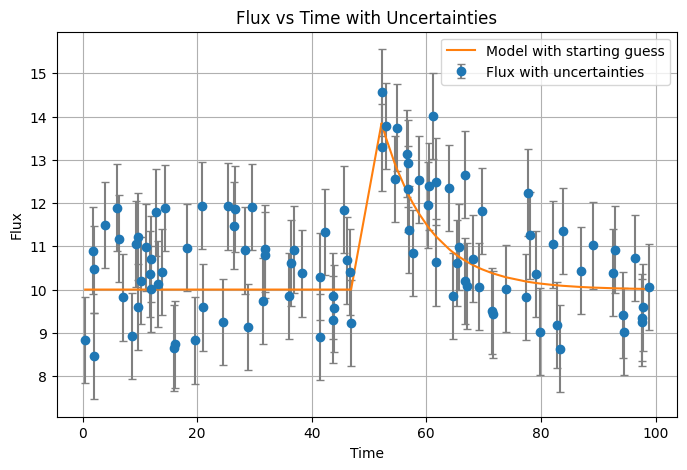

In [50]:
labels = ["b","t0","A","alpha"]

# Load the data
data = np.load('transient.npy')
time = data[:, 0]
flux = data[:, 1]
uncertainties = data[:, 2]

# Create the errorbar plot with the model and initial guess
plt.figure(figsize=(8, 5))
plt.errorbar(time, flux, yerr=uncertainties, fmt='o', 
             ecolor='gray', capsize=3, label='Flux with uncertainties')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Flux vs Time with Uncertainties')

starting_guesses = np.array([10,50,5,0.12])
plt.plot(time,model(starting_guesses,time),label='Model with starting guess')
plt.legend()
plt.grid(True)

print("\n".join([f"Starting guess for {label} is {value}" for label, value in zip(labels, starting_guesses)]))

Initialize and run the sampler. Compute the evidence and the weighted samples

In [55]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(logLikelihood, ptform_burst, ndim,logl_args=(burst,time, flux, uncertainties))
sampler.run_nested()
sresults = sampler.results

7714it [02:27, 52.46it/s, +500 | bound: 183 | nc: 1 | ncall: 155051 | eff(%):  5.315 | loglstar:   -inf < -140.667 <    inf | logz: -155.305 +/-  0.168 | dlogz:  0.001 >  0.509]


b: median = 10.3013, 5th = 10.1002, 95th = 10.4946. 90% credible region: 10.3013(+0.193351, -0.201094)
t0: median = 49.0146, 5th = 47.0850, 95th = 51.8495. 90% credible region: 49.0146(+2.834882, -1.929624)
A: median = 5.4476, 5th = 3.5719, 95th = 8.9756. 90% credible region: 5.4476(+3.528018, -1.875709)
alpha: median = 0.1234, 5th = 0.0848, 95th = 0.1781. 90% credible region: 0.1234(+0.054726, -0.038629)


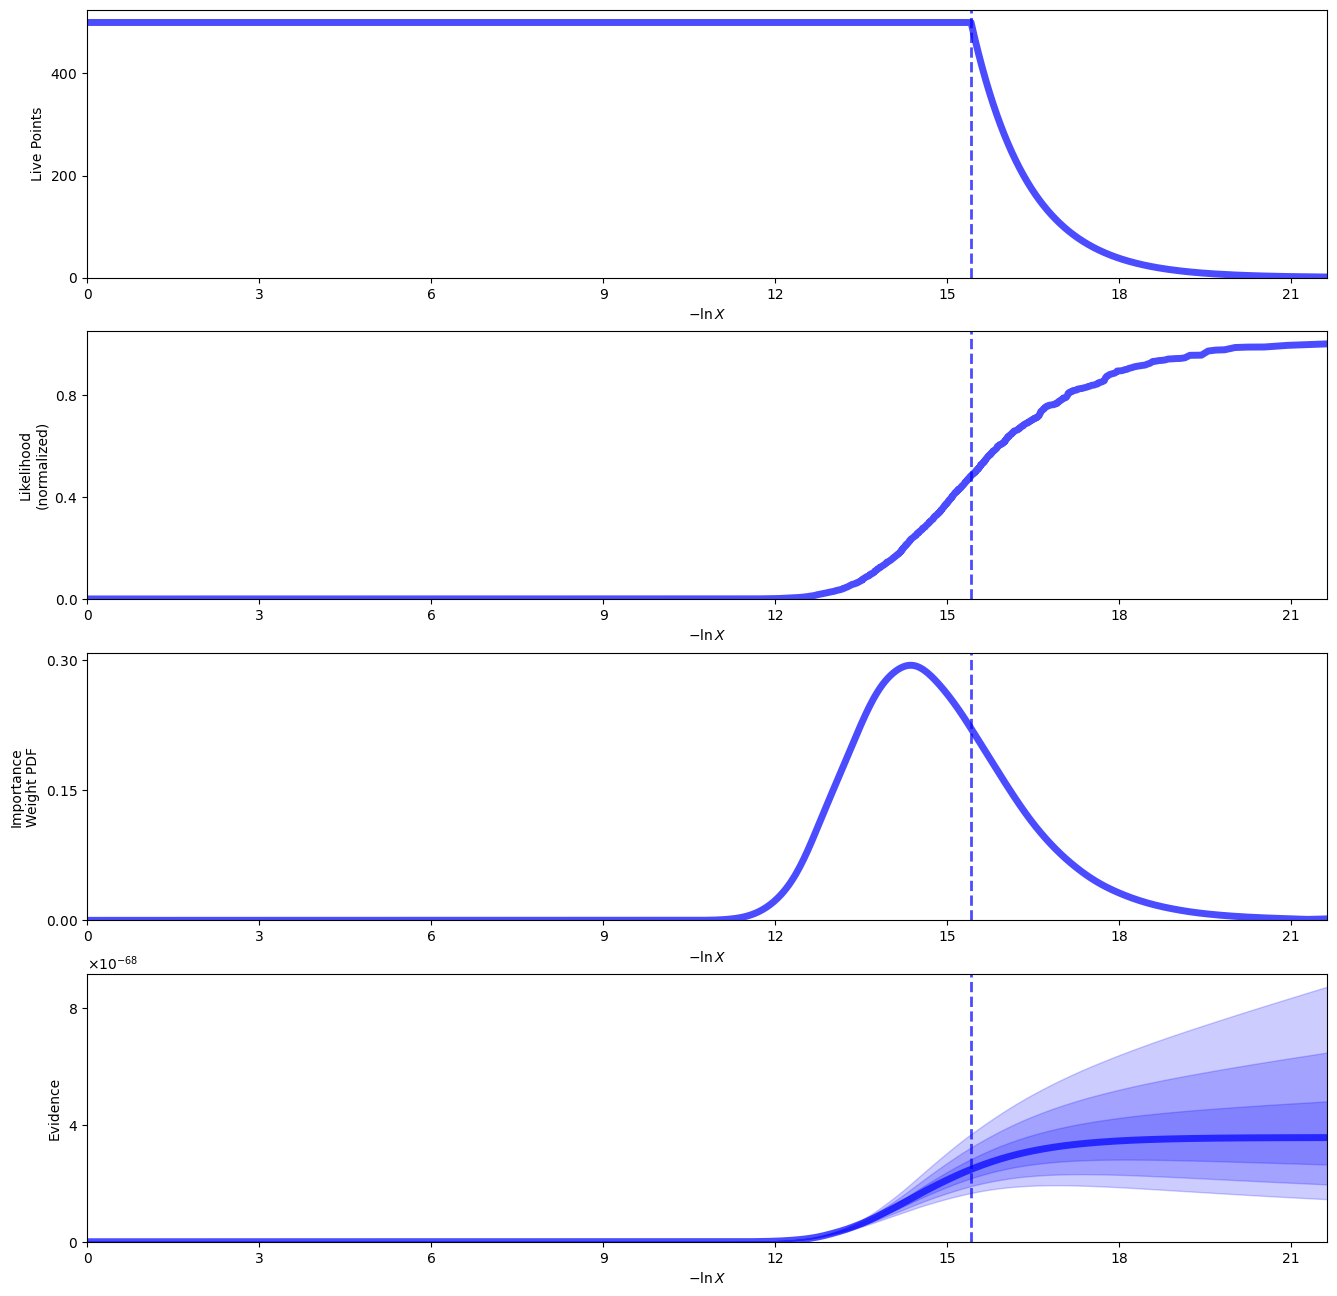

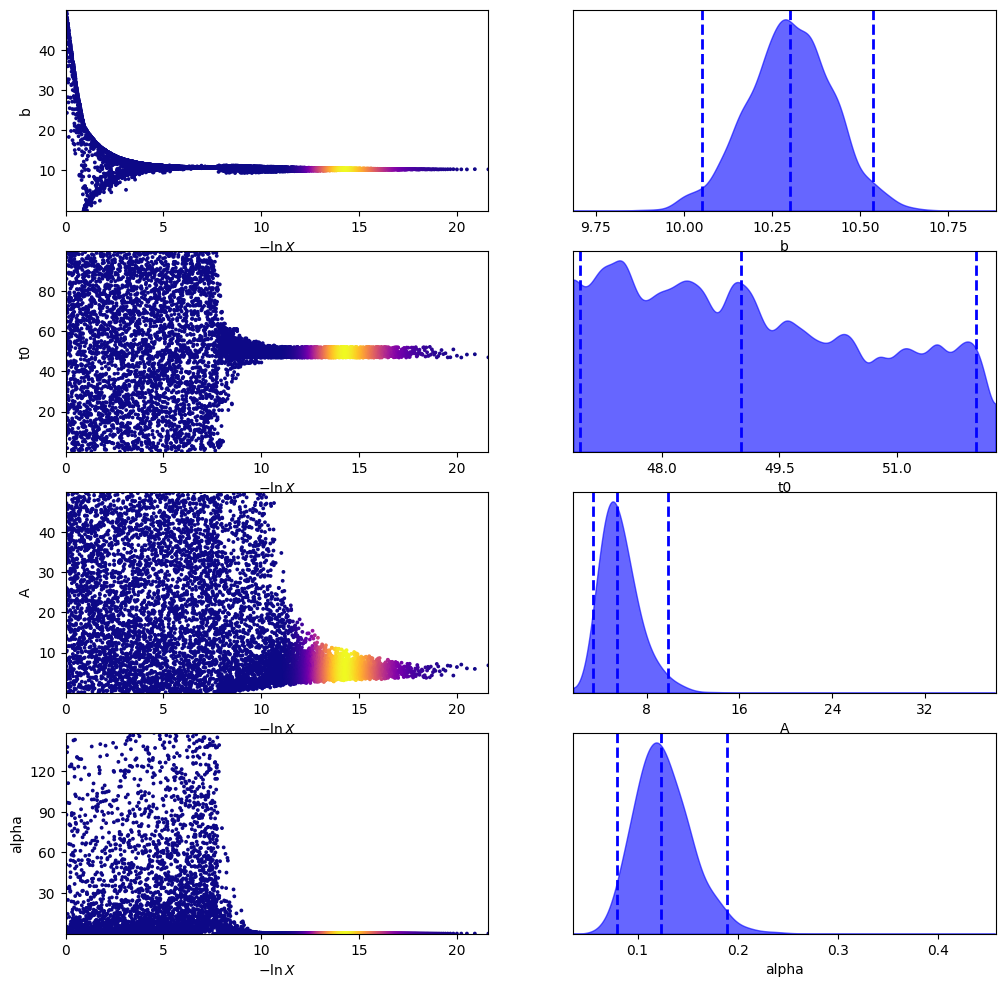

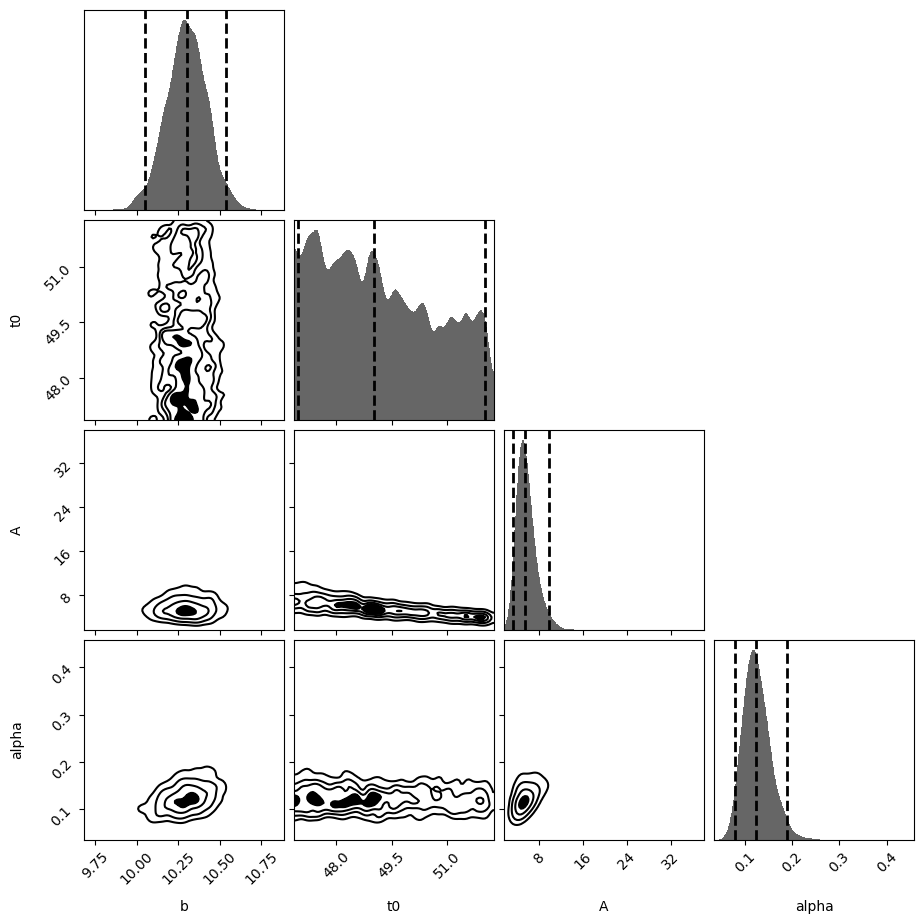

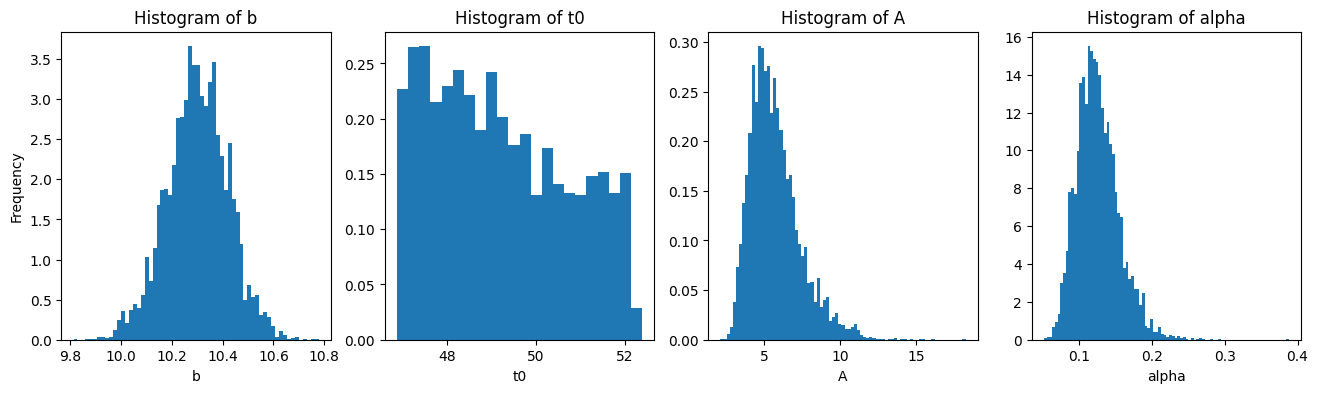

In [62]:
Z_burst = plot(labels,sresults)

Change model and prior

In [63]:
def gauss(x, time):

    b, t0, A, sigma = x
    y = b + A * np.exp(-((time - t0)**2)/(2*sigma**2))
    return y

def ptform_gauss(u):
    b, t0, A, sigma = u
    b = 50 * b           # Uniform in [0, 50]
    t0 = 100 * t0         # Uniform in [0, 100]
    A = 50 * A           # Uniform in [0, 50]
    sigma = 0 + 10 * sigma   # Uniform in [-5, 5]
    return np.array([b, t0, A, sigma])

Run the sampler

In [64]:
labels = ["b","t0","A","sigma"]
# "Static" nested sampling.
sampler = dynesty.NestedSampler(logLikelihood, ptform_gauss, ndim,logl_args=(gauss,time, flux, uncertainties))
sampler.run_nested()
sresults = sampler.results

7620it [01:17, 97.87it/s, +500 | bound: 103 | nc: 1 | ncall: 94450 | eff(%):  8.643 | loglstar:   -inf < -144.313 <    inf | logz: -158.826 +/-  0.170 | dlogz:  0.001 >  0.509]


b: median = 10.3122, 5th = 10.1036, 95th = 10.5169. 90% credible region: 10.3122(+0.204674, -0.208653)
t0: median = 55.5068, 5th = 53.8701, 95th = 57.1242. 90% credible region: 55.5068(+1.617389, -1.636737)
A: median = 2.7176, 5th = 2.1143, 95th = 3.3766. 90% credible region: 2.7176(+0.658904, -0.603328)
sigma: median = 5.4062, 5th = 4.0668, 95th = 6.9172. 90% credible region: 5.4062(+1.510935, -1.339455)


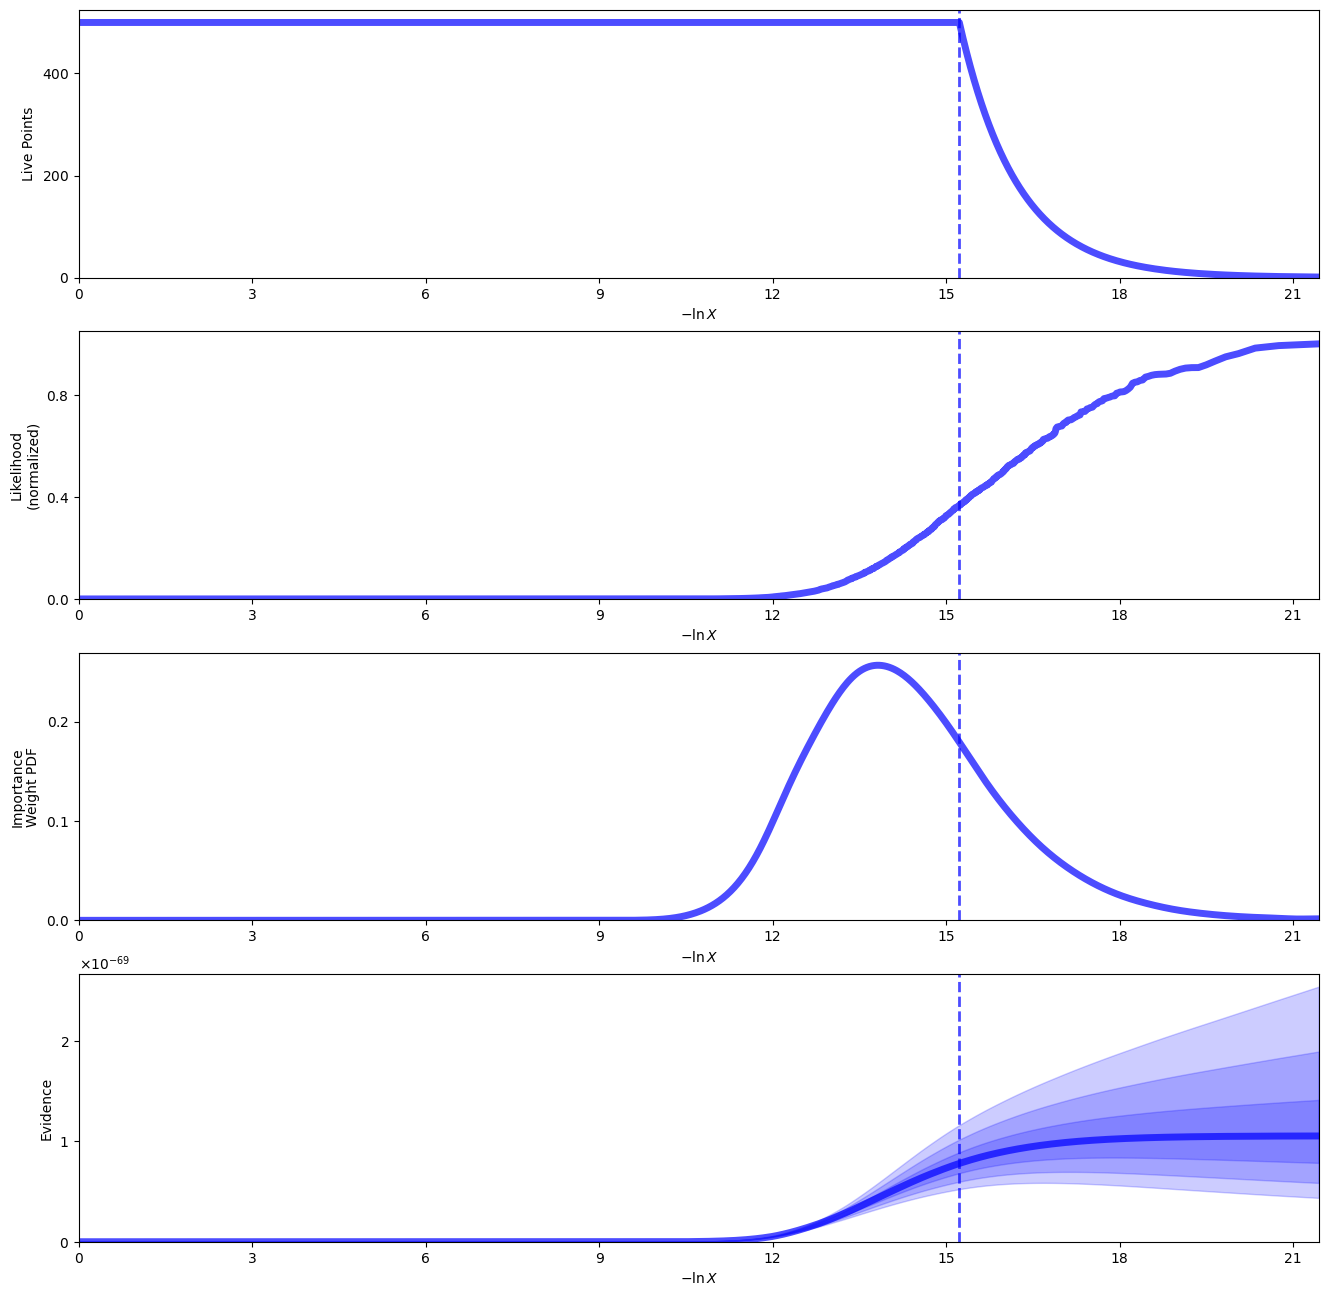

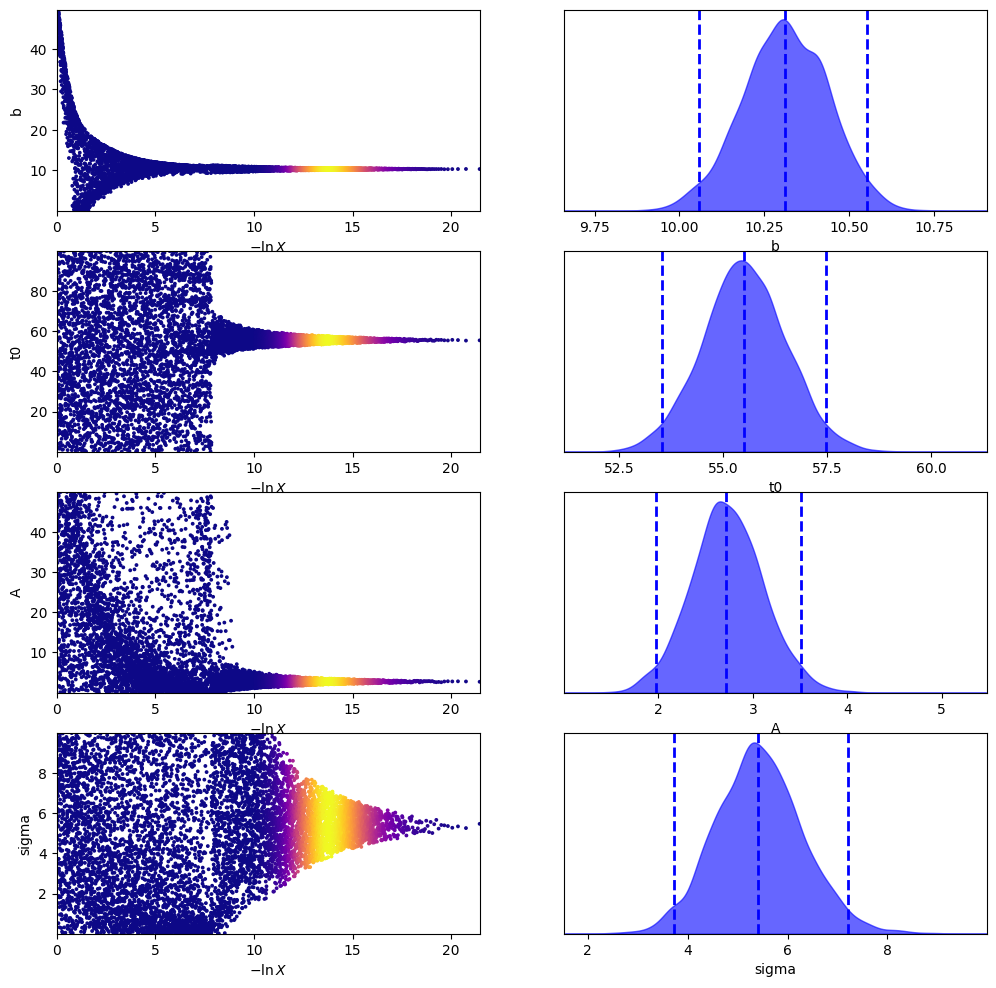

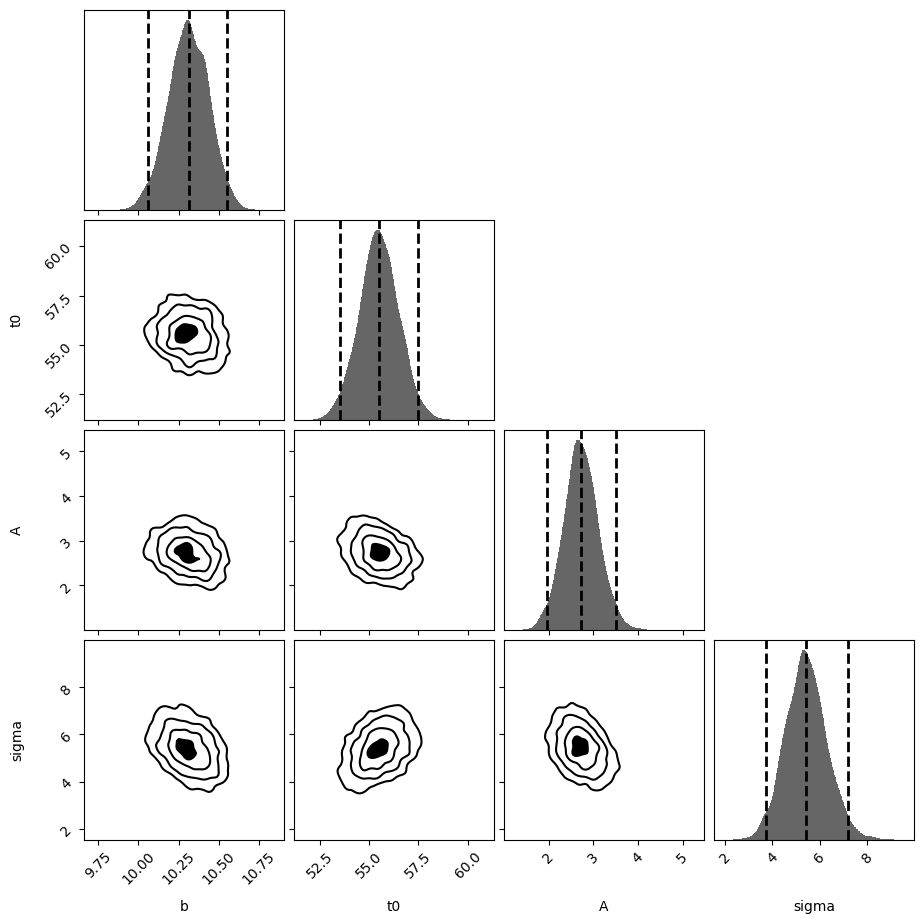

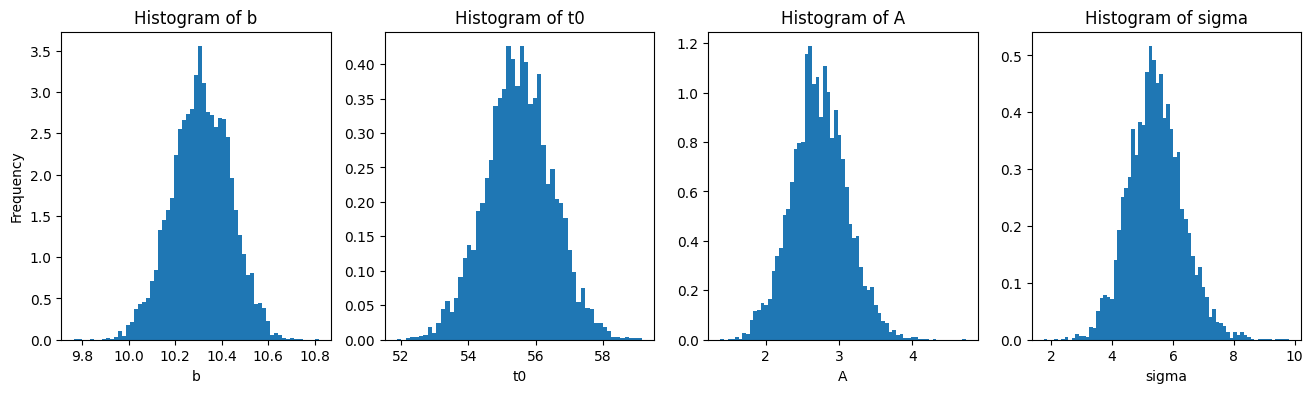

In [65]:
Z_gauss = plot(labels, sresults)

In [67]:
print('The Bayes factor of burst vs gauss is: ', np.log(Z_burst/Z_gauss), ' meaning that the burst model is the favorite')

The Bayes factor of burst vs gauss is:  3.5209007021819616  meaning that the burst model is the favorite


Plot some models

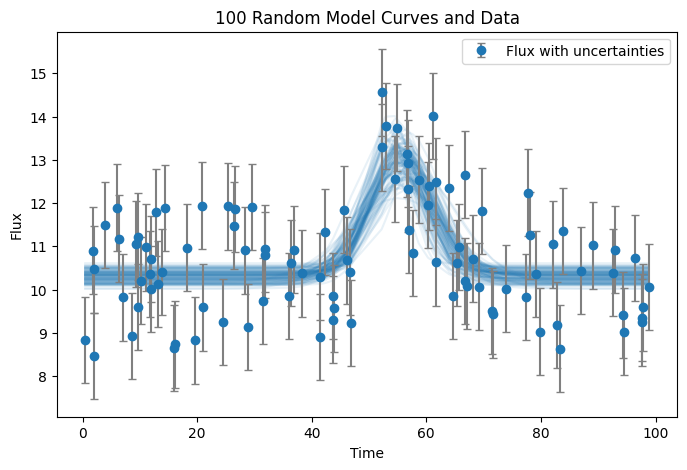

In [68]:
weights = sresults.importance_weights()
samples = sresults.samples
samples_equal = dyfunc.resample_equal(samples, weights)


models = np.array([gauss(params, time) for params in samples_equal])
random_indices = np.random.choice(models.shape[0], size=100, replace=False)

plt.figure(figsize=(8, 5))

# Plot 100 random model curves with transparency
for idx in random_indices:
    plt.plot(time, models[idx, :], color='C0', alpha=0.1)

plt.errorbar(time, flux, yerr=uncertainties, fmt='o', 
             ecolor='gray', capsize=3, label='Flux with uncertainties')

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("100 Random Model Curves and Data")
plt.legend()

